# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [4]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


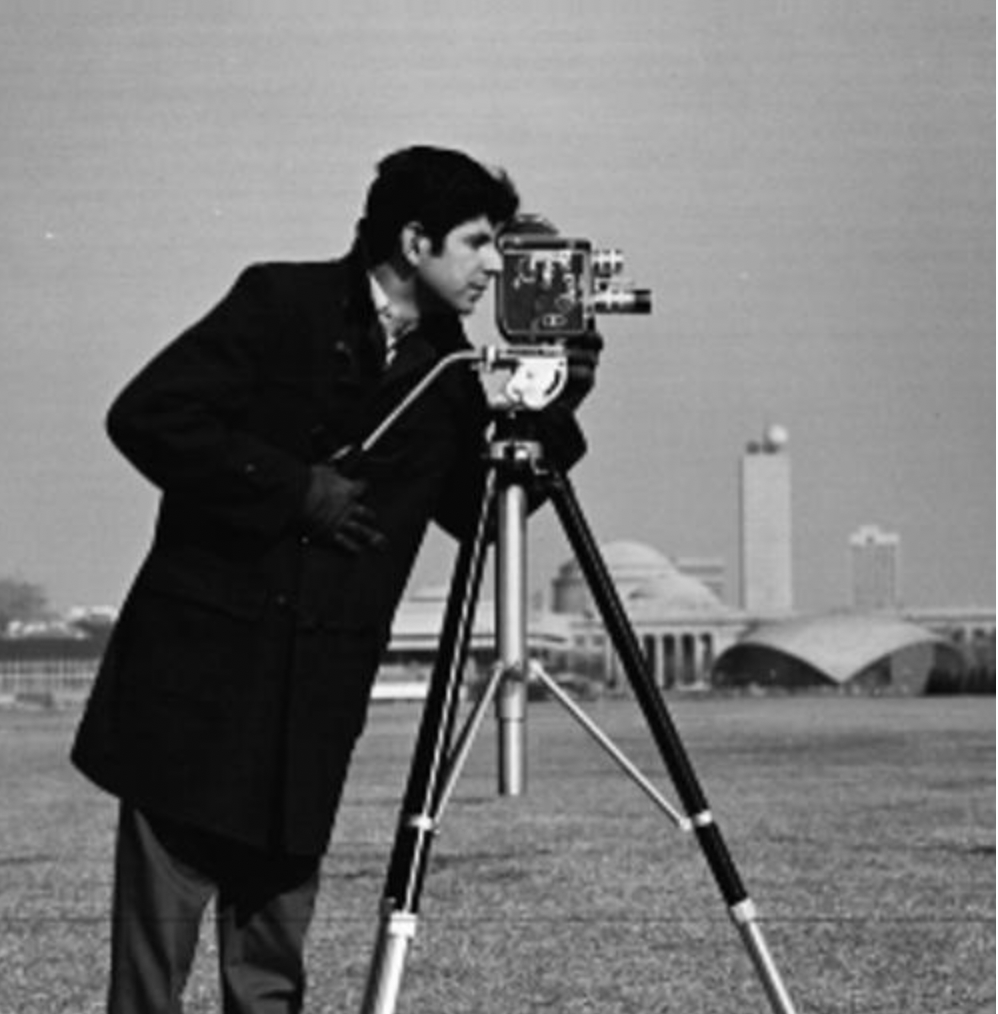

In [9]:
# ── Load image ────────────────────────────────────
image_path = "/Users/wadhaalbaker/Desktop/img11.png"  # TODO: replace with the path to your own image
img = Image.open(image_path).convert("L")  # convert to grayscale
img


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [12]:
# Get the size of the image
width, height = img.size
print("Original size:", width, height)

# scaling factors
scale_x = 2
scale_y = 2


Original size: 998 1014


In [14]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * scale_x)
new_height = int(height * scale_y)

# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)


In [16]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (998, 1014)
Scaled size: (1996, 2028)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [19]:
# non-uniform scaling factors
cx = 2  # stretch horizontally
cy = 1  # leave vertical size unchanged


In [21]:
# Compute the new (stretched) size and resize
stretched_width = int(width * cx)
stretched_height = int(height * cy)

stretched_img = img.resize((stretched_width, stretched_height), Image.LANCZOS)


In [23]:
# Save the non-uniformly scaled image and print the sizes
stretched_img.save("task1_1b_stretched.jpg")
print("Original size:", img.size)
print("Stretched size:", stretched_img.size)


Original size: (998, 1014)
Stretched size: (1996, 1014)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [26]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated size:", rotated_img.size)


Original size: (998, 1014)
Rotated size: (1378, 1372)


### 3. Shear

In [29]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Original size:", width, height)


Original size: 998 1014


In [31]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# X-axis shear (set shy instead, and shx = 0, for Y-axis shear)
shx = shear_factor
shy = 0

# Translation so the sheared content stays inside the new canvas
tx = -shx * height if shx > 0 else 0
ty = -shy * width if shy > 0 else 0

# New canvas size needed to fit the sheared image (update this multiplier if you change shear_factor)
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)


In [33]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    (1, shx, tx, shy, 1, ty),
    resample=Image.BICUBIC
)


In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print("Original size:", img.size)
print("Sheared size:", sheared_img.size)


Original size: (998, 1014)
Sheared size: (1505, 1014)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

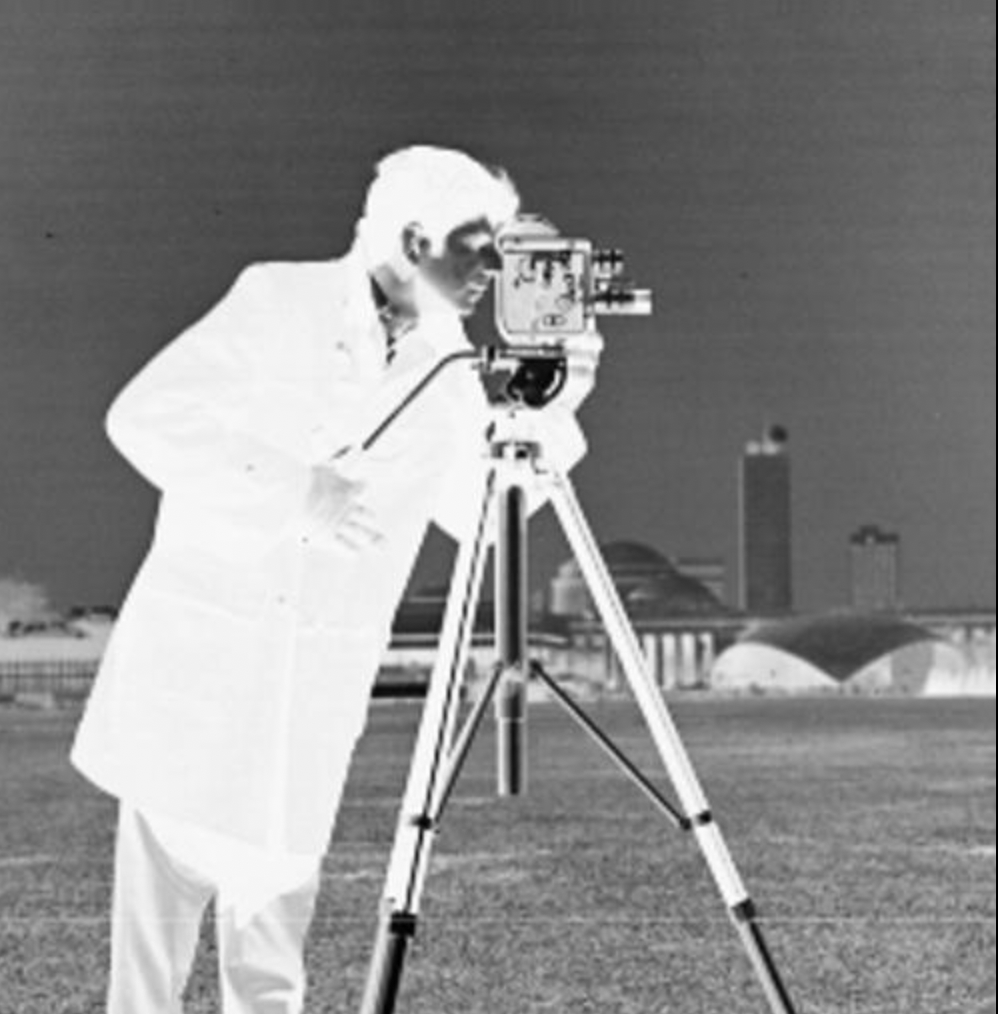

In [40]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img_np = Image.fromarray(negative_arr.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np


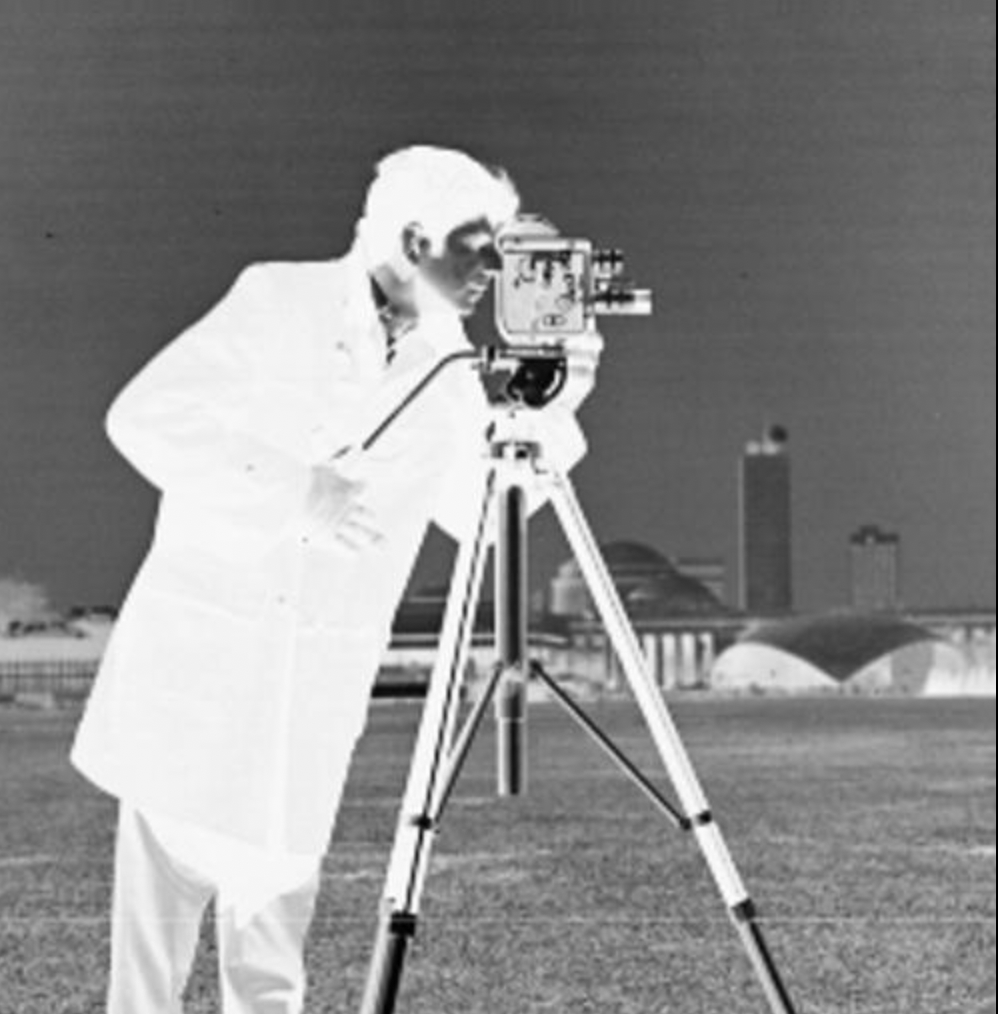

In [42]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)
negative_img_pil.save("task2_1_negative_pil.jpg")
negative_img_pil


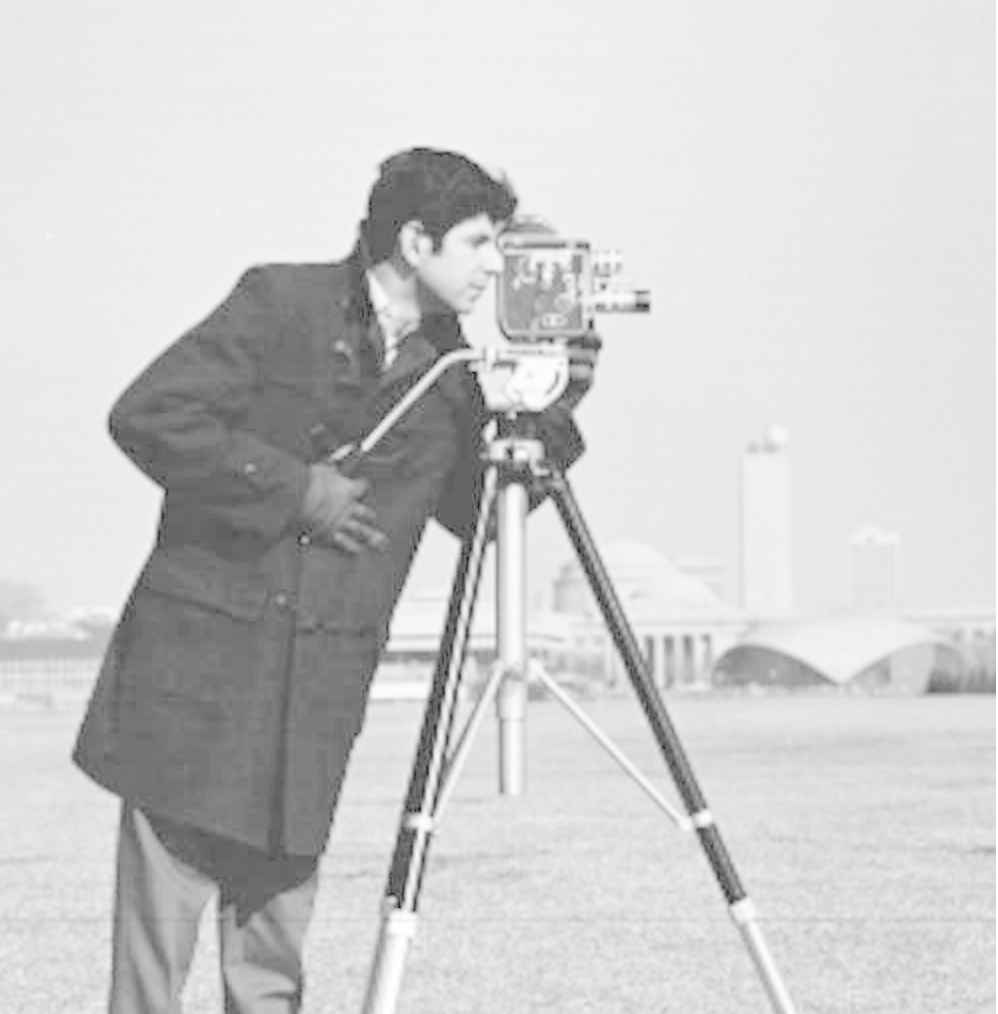

In [44]:
# ── 2. Log transformation ──────────────────────────
# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Use float so "1 + r" can't overflow/wrap the way uint8 would
arr = np.array(img, dtype=np.float64)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_img = Image.fromarray(np.uint8(log_transformed_arr))
log_img.save("task2_2_log.jpg")
log_img


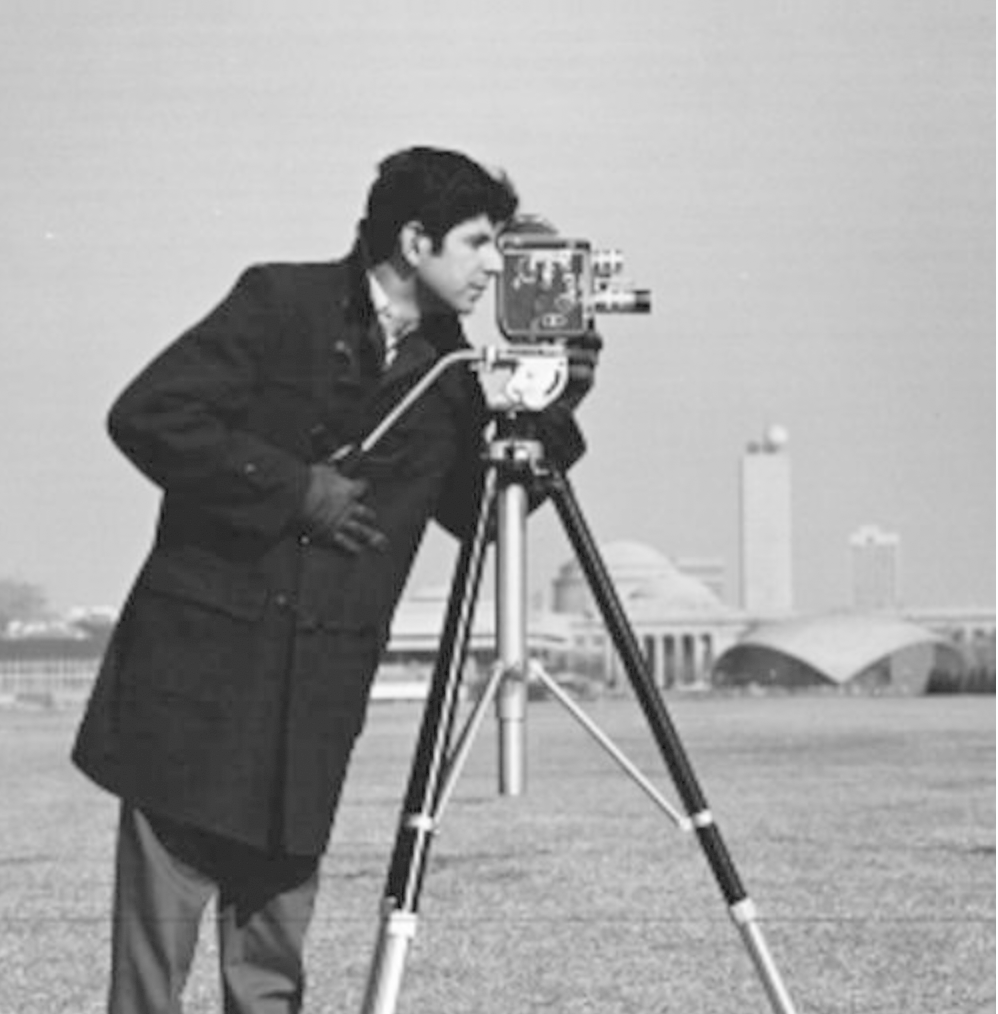

In [46]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5  # < 1 brightens the image, > 1 darkens it — experiment with different values

arr_norm = np.array(img, dtype=np.float64) / 255.0
gamma_transformed_arr = np.power(arr_norm, gamma) * 255.0
gamma_img = Image.fromarray(np.uint8(gamma_transformed_arr))
gamma_img.save("task2_3_gamma.jpg")
gamma_img


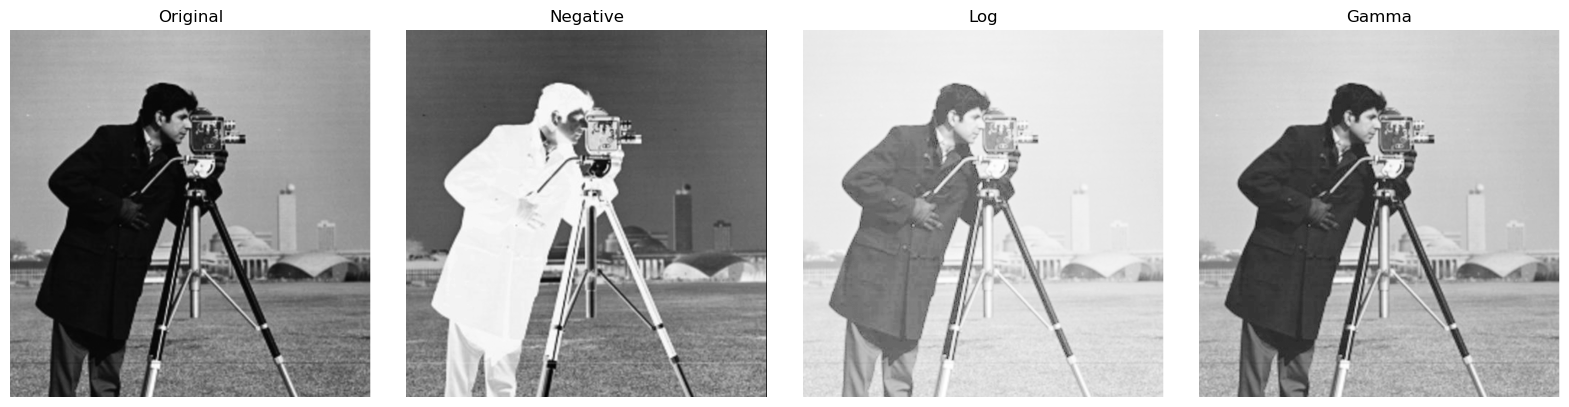

In [48]:
# Compare the original image against the three intensity transformations
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original", "Negative", "Log", "Gamma"]
images = [img, negative_img_pil, log_img, gamma_img]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()
